# ConnMatrixHops Demo

Demonstrates N-hop signal flow visualization using the toy connectivity data.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

import pandas as pd
from connmatrixhops import MatrixAnalyzer

DATA_DIR = '/data/toy_data' if os.path.exists('/data/toy_data') else '../../data/toy_data'

## Load Toy Data

Edge list with `pre_id`, `post_id`, `synapse_size` and cluster metadata.

In [2]:
edge_list = pd.read_csv(os.path.join(DATA_DIR, 'edge_list.csv'))
metadata = pd.read_csv(os.path.join(DATA_DIR, 'cluster_assignments.csv'))

print(edge_list.head())
print(metadata.head())

   pre_id  post_id  synapse_size
0       0       73      0.188048
1       0       73      0.383714
2       0       73      0.285053
3       0      124      0.868837
4       0      129      0.197316
   cell_id cluster_label
0        0             A
1        1             A
2        2             A
3        3             A
4        4             A


## Initialize MatrixAnalyzer

Using default columns (`pre_id`, `post_id`, `synapse_size`) with sum aggregation.

In [3]:
analyzer = MatrixAnalyzer(
    edge_list=edge_list,
    metadata=metadata,
    source_col='pre_id',
    target_col='post_id',
    weight_col='synapse_size',
    weight_agg_func='sum',
    cell_id_col='cell_id',
    cluster_col='cluster_label',
)

## Full Connectivity Matrix

Visualize the complete cell-to-cell connectivity matrix (sorted by cluster) before extracting any hop submatrices.

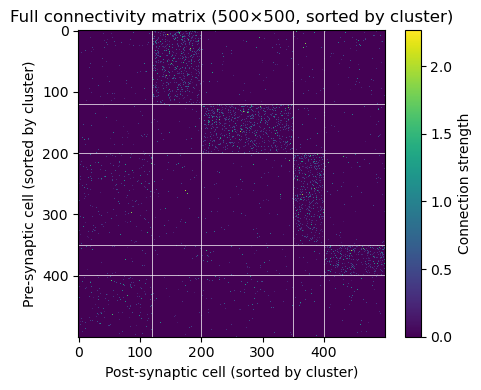

In [13]:
import matplotlib.pyplot as plt
import numpy as np

matrix = analyzer._matrix
sorted_idx = analyzer._sorted_indices if analyzer._sorted_indices is not None else np.arange(matrix.shape[0])
sorted_matrix = matrix[np.ix_(sorted_idx, sorted_idx)]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sorted_matrix, cmap='viridis', aspect='equal', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Connection strength')
ax.set_xlabel('Post-synaptic cell (sorted by cluster)')
ax.set_ylabel('Pre-synaptic cell (sorted by cluster)')
ax.set_title(f'Full connectivity matrix ({matrix.shape[0]}×{matrix.shape[1]}, sorted by cluster)')

# Cluster boundary lines
if analyzer.metadata is not None and analyzer.cluster_col is not None:
    cluster_for_sorted = [
        analyzer.metadata.set_index(analyzer.cell_id_col)[analyzer.cluster_col]
        .get(analyzer._idx_to_id[i])
        for i in sorted_idx
    ]
    boundaries = []
    for k in range(1, len(cluster_for_sorted)):
        if cluster_for_sorted[k] != cluster_for_sorted[k - 1]:
            boundaries.append(k)
    for b in boundaries:
        ax.axhline(b - 0.5, color='white', linewidth=0.5)
        ax.axvline(b - 0.5, color='white', linewidth=0.5)

plt.tight_layout()
plt.show()

## Plot Flow by Cluster Name

Seed with cluster "A" and trace 4 hops downstream (all targets).

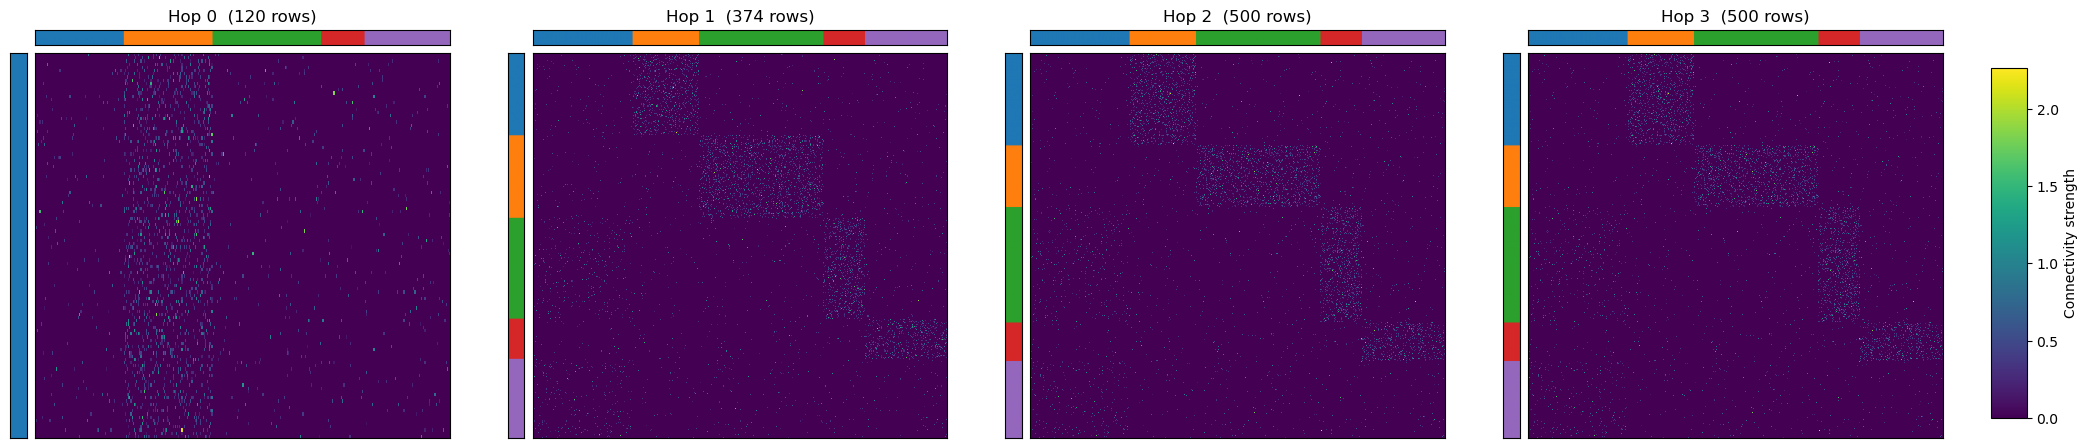

In [4]:
fig = analyzer.plot_flow('A', n_steps=4);

## Top-Percent Filtering

Only carry forward the top 10% of targets (ranked by incoming connection strength) at each hop.
This narrows the view to the strongest-connected pathway through the network.

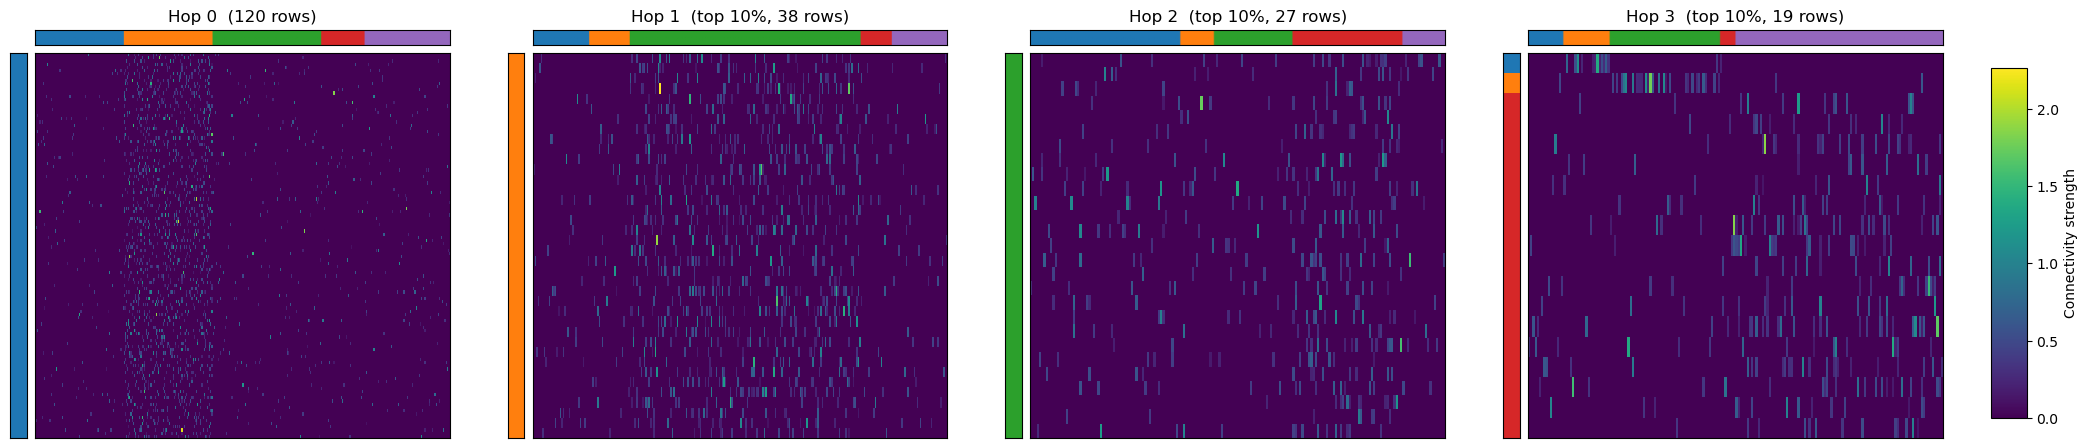

In [6]:
fig = analyzer.plot_flow('A', n_steps=4, top_percent=0.1)

## Plot Flow by Cell IDs

Seed with a few specific neurons, top 20% filtering.

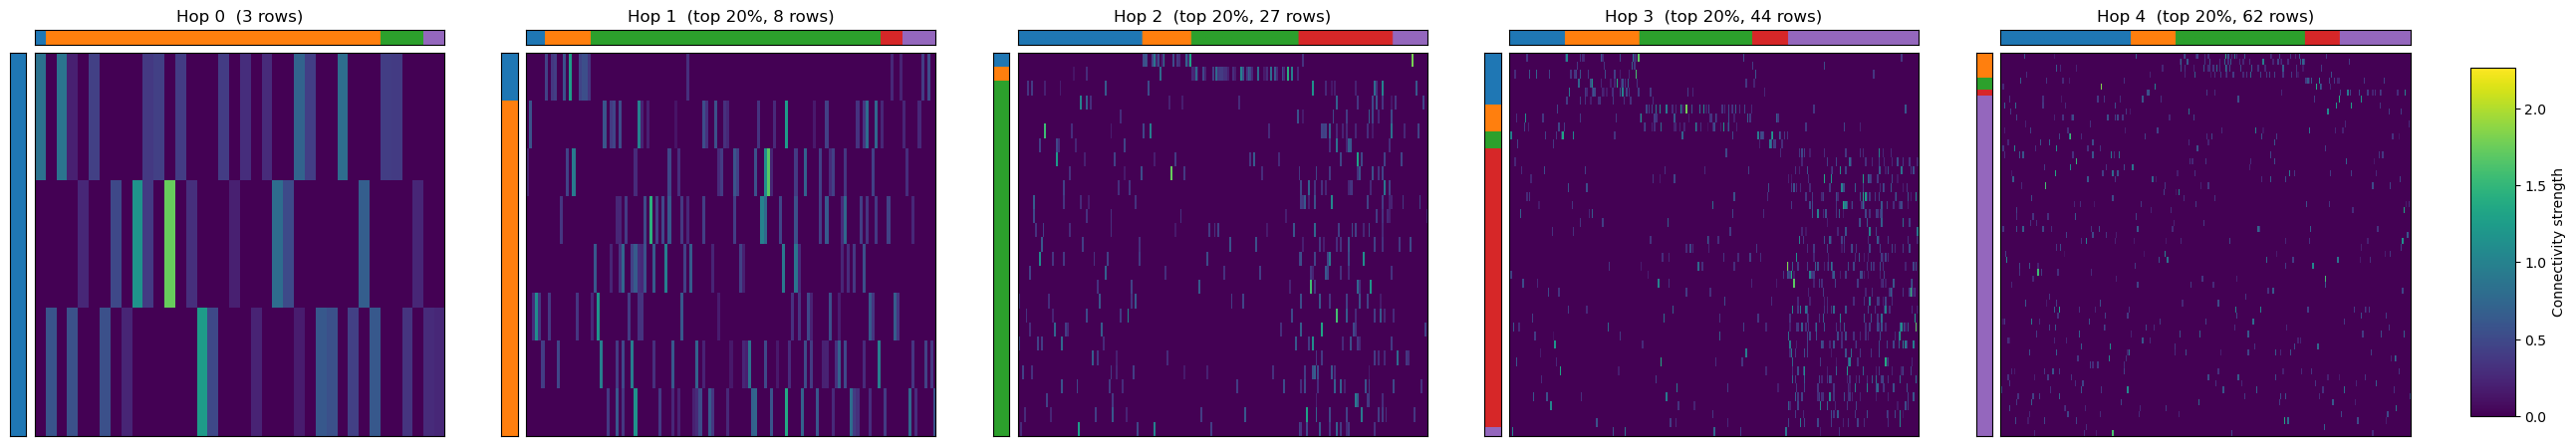

In [7]:
fig = analyzer.plot_flow([0, 1, 2], n_steps=5, top_percent=0.2)

## Interactive Widget

Use dropdown to select cluster, slider for number of hops, and slider for top-percent filtering.

Output()

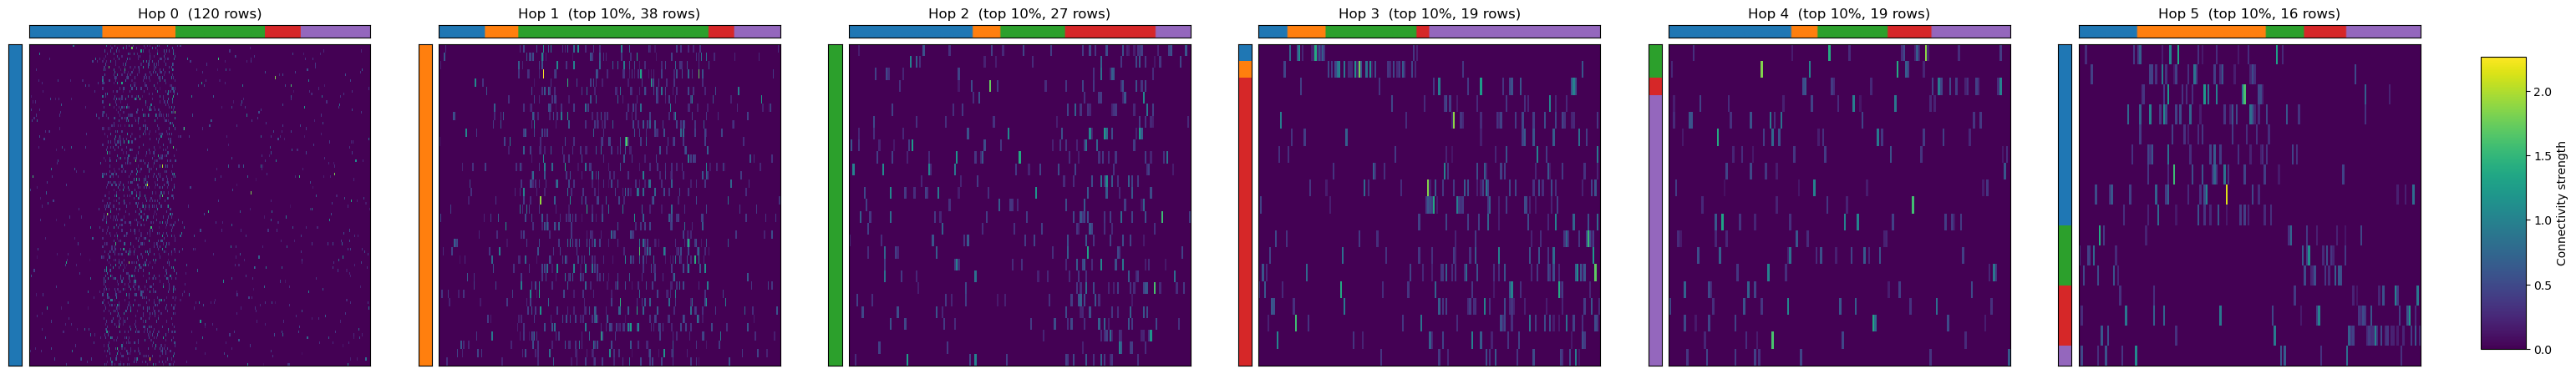

In [10]:
from connmatrixhops import ConnMatrixHopsWidget

widget = ConnMatrixHopsWidget(analyzer, default_n_hops=6, default_top_percent=0.1)
widget.interactive(cluster_dropdown=True, n_hops_slider=True, top_percent_slider=True)